In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")

Load Data


In [7]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")


folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [8]:
print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Fund Master:", fund_master.shape)
print("SIP:", sip.shape)
print("Folio:", folio.shape)
print("Portfolio:", portfolio.shape)

NAV: (46000, 3)
Performance: (40, 19)
Transactions: (32778, 13)
Fund Master: (40, 15)
SIP: (48, 6)
Folio: (21, 6)
Portfolio: (322, 8)


Check the Column Names

In [10]:
print("NAV Columns")
print(nav.columns.tolist())

print("\nPerformance Columns")
print(performance.columns.tolist())

print("\nTransactions Columns")
print(transactions.columns.tolist())

print("\nSIP Columns")
print(sip.columns.tolist())

print("\nFolio Columns")
print(folio.columns.tolist())

NAV Columns
['amfi_code', 'date', 'nav']

Performance Columns
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Transactions Columns
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

SIP Columns
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Folio Columns
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


Chart 1: Daily NAV Trend

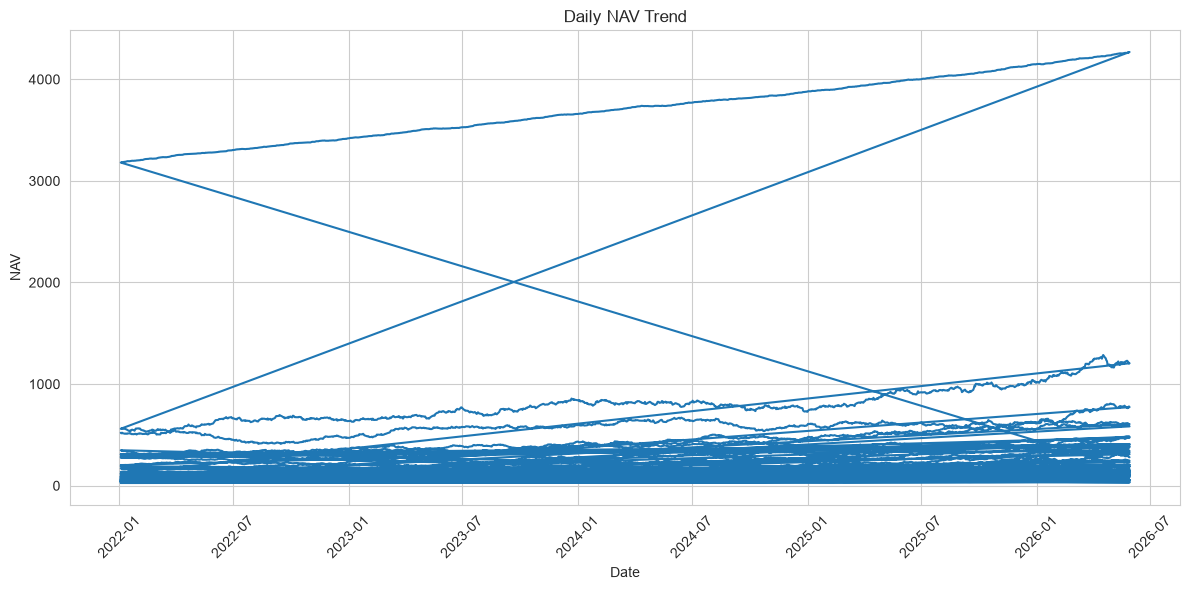

In [12]:
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(12,6))
plt.plot(nav["date"], nav["nav"])

plt.title("Daily NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../dashboard/charts/nav_trend.png")
plt.show()


Chart 2: Top 10 Fund Houses by AUM

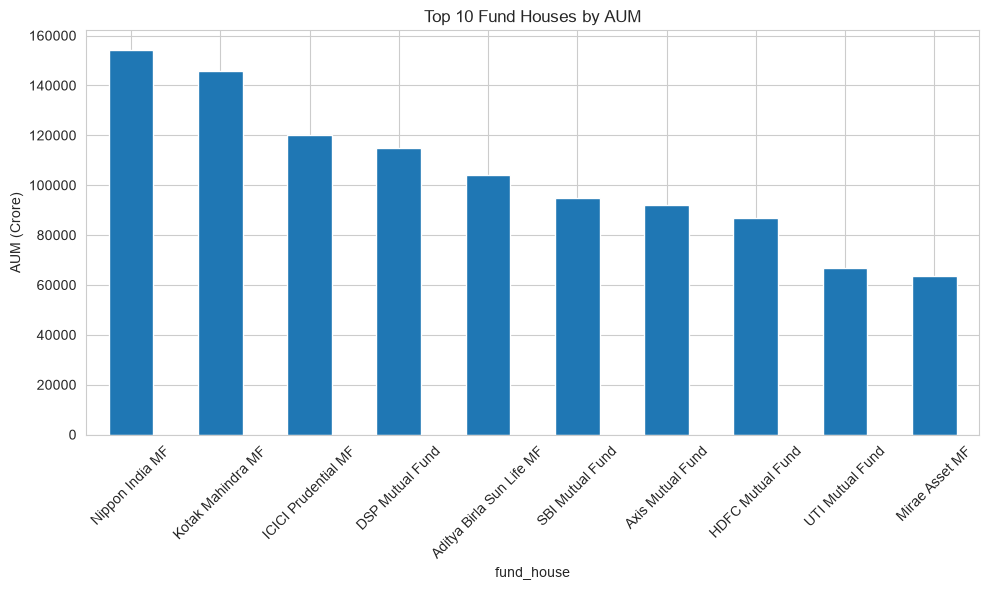

In [13]:
top_aum = (
    performance.groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_aum.plot(kind="bar")

plt.title("Top 10 Fund Houses by AUM")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../dashboard/charts/top_aum.png")
plt.show()

Chart 3: Monthly SIP Inflows

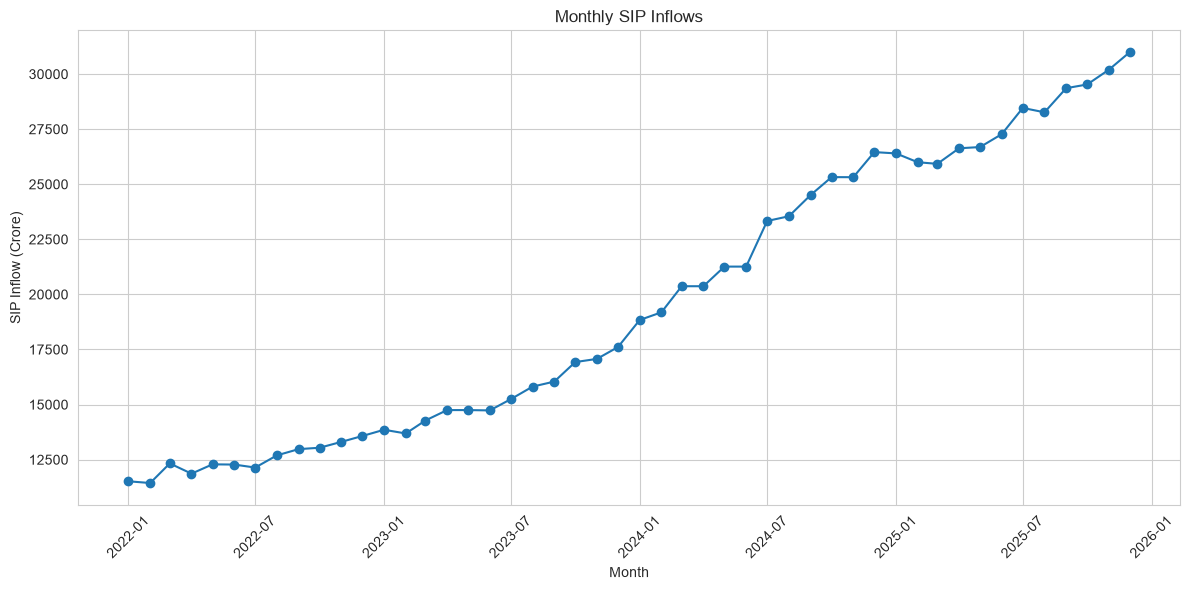

In [14]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))
plt.plot(sip["month"], sip["sip_inflow_crore"], marker="o")

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../dashboard/charts/sip_trend.png")
plt.show()

Chart 4: Transaction Type Distributio

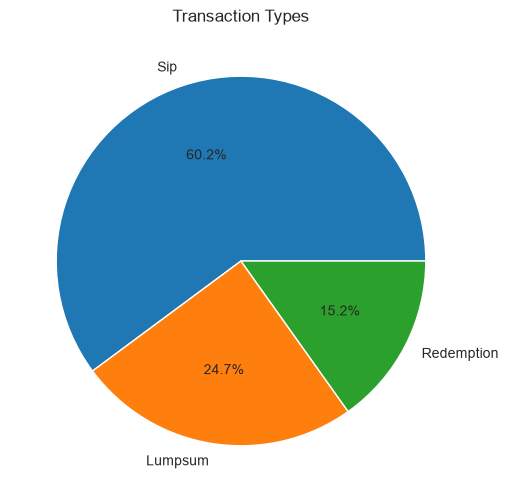

In [15]:
transactions["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Transaction Types")

plt.ylabel("")
plt.savefig("../dashboard/charts/transaction_type.png")
plt.show()

Chart 5: Gender Distribution

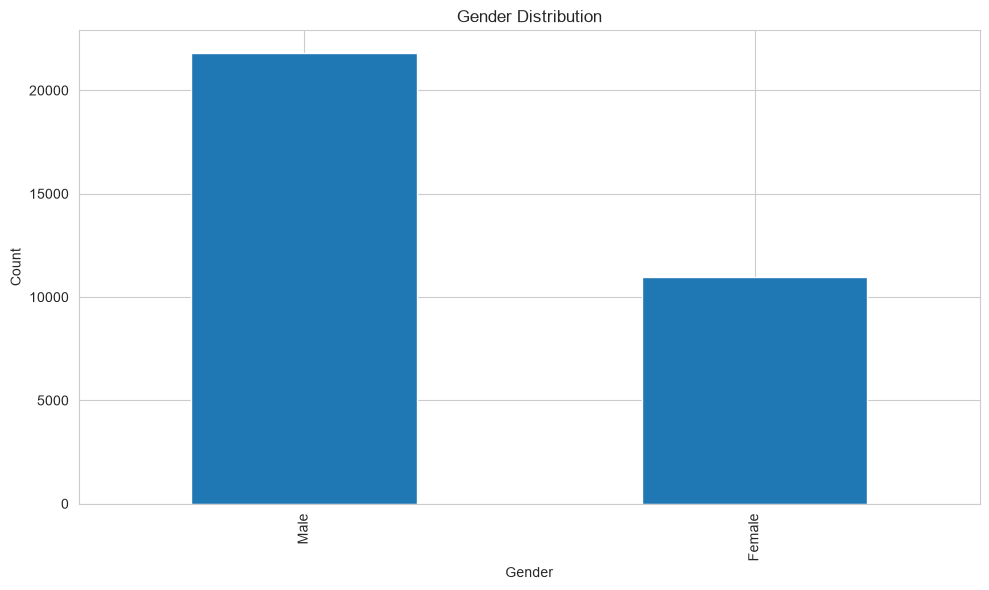

In [16]:
transactions["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../dashboard/charts/gender_distribution.png")
plt.show()

Chart 6: Age Group Distribution

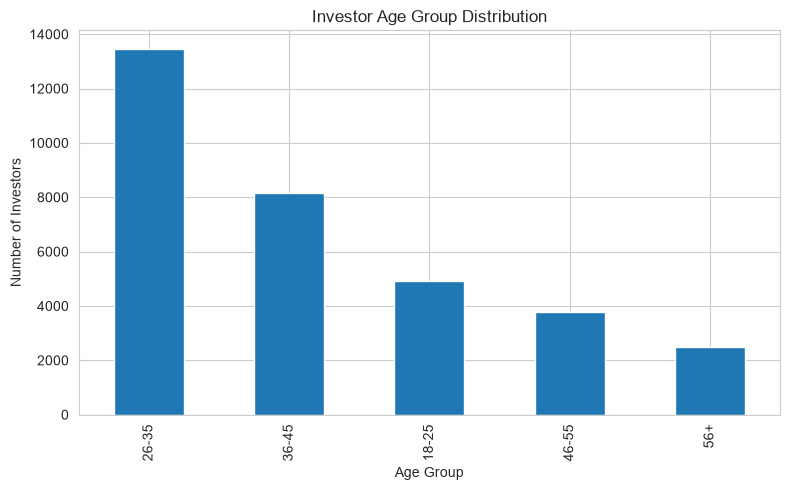

In [17]:
transactions["age_group"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.tight_layout()
plt.savefig("../dashboard/charts/age_group_distribution.png")
plt.show()

Chart 7:State-wise Investment Amount

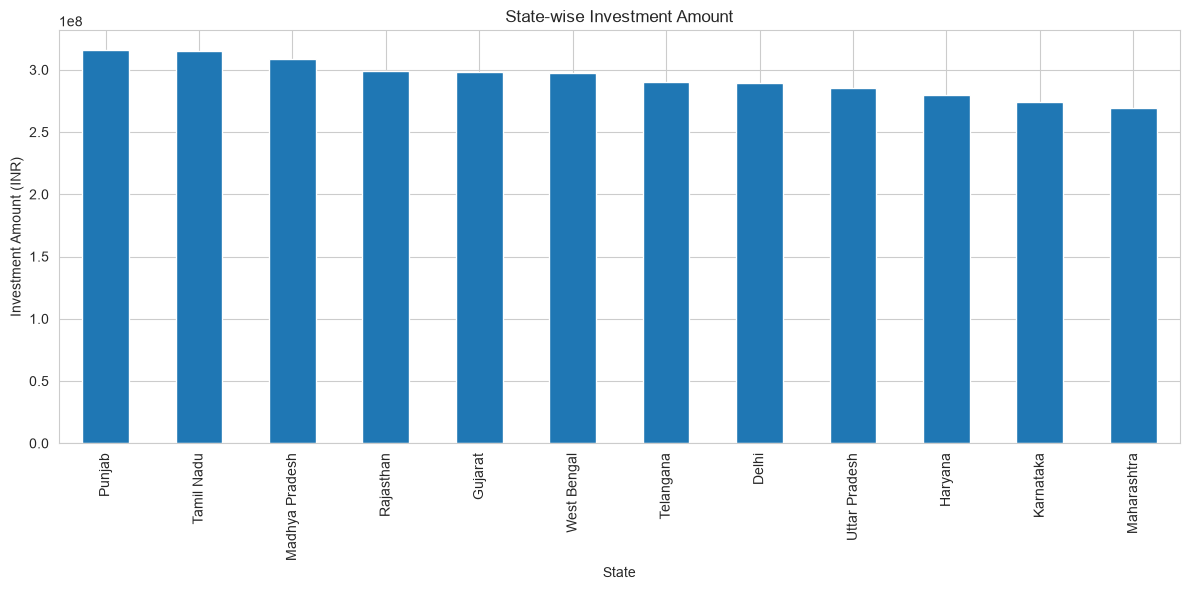

In [18]:
state_investment = transactions.groupby("state")["amount_inr"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_investment.plot(kind="bar")

plt.title("State-wise Investment Amount")
plt.xlabel("State")
plt.ylabel("Investment Amount (INR)")

plt.tight_layout()
plt.savefig("../dashboard/charts/state_investment.png")
plt.show()

Chart 8: City Tier Distribution

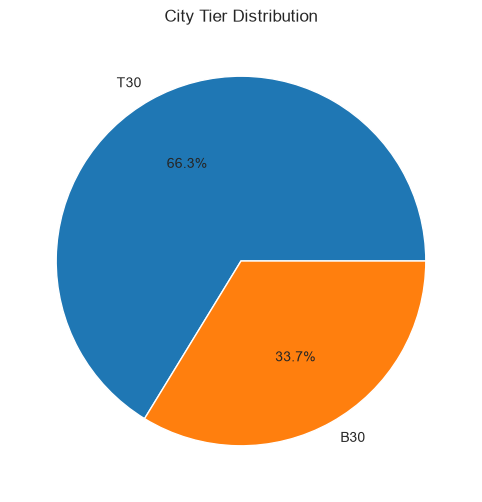

In [19]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("City Tier Distribution")
plt.ylabel("")

plt.savefig("../dashboard/charts/city_tier_distribution.png")
plt.show()

Chart 9: Expense Ratio Distribution

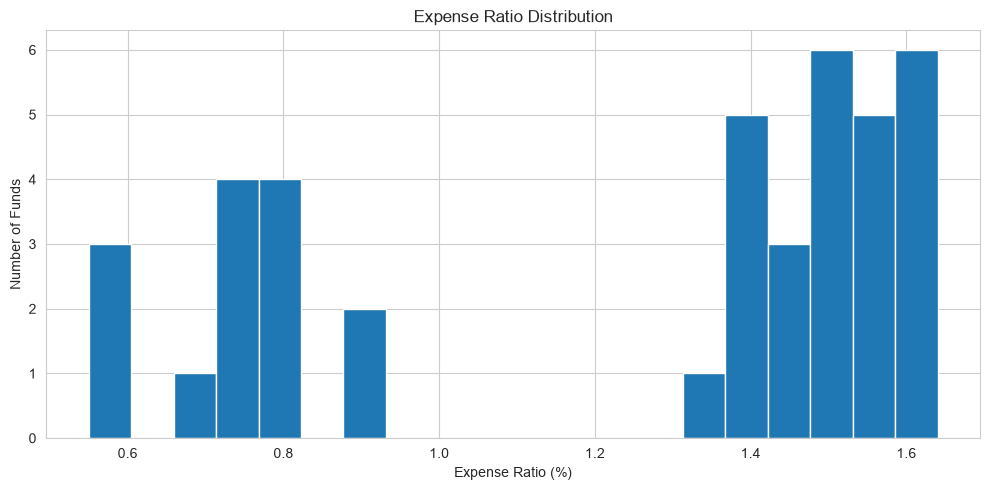

In [20]:
plt.figure(figsize=(10,5))
plt.hist(performance["expense_ratio_pct"], bins=20)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")

plt.tight_layout()
plt.savefig("../dashboard/charts/expense_ratio_distribution.png")
plt.show()

Chart 10: Risk Grade Distribution

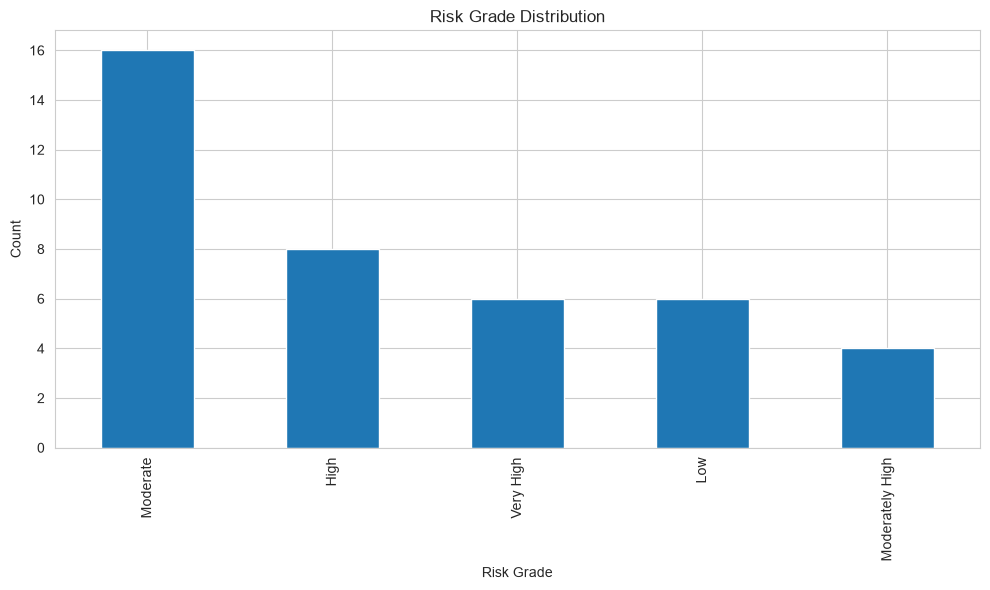

In [21]:
performance["risk_grade"].value_counts().plot(kind="bar")

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../dashboard/charts/risk_grade_distribution.png")
plt.show()

Chart 11: Morningstar Rating Distribution

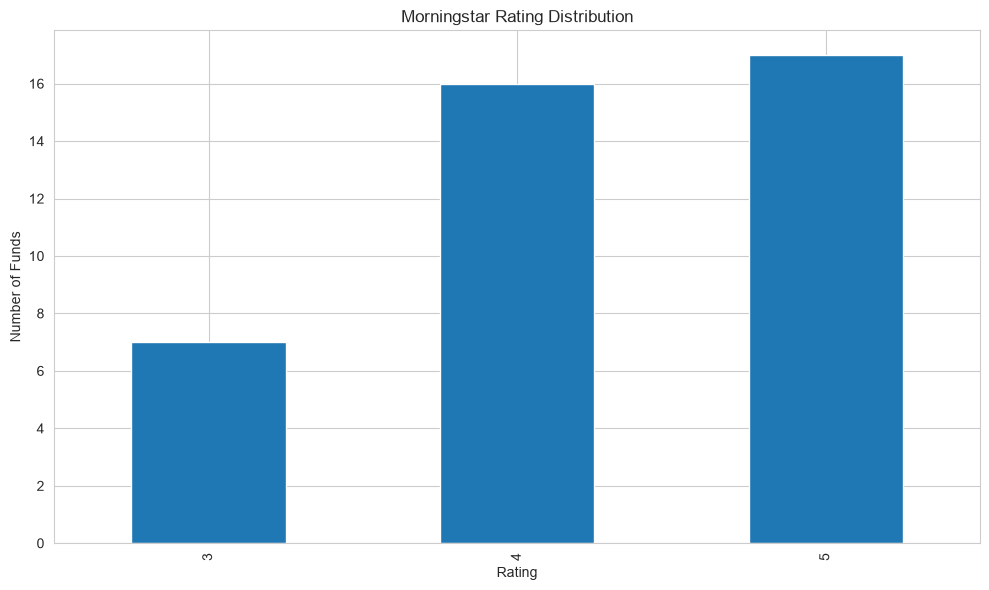

In [22]:
performance["morningstar_rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.tight_layout()
plt.savefig("../dashboard/charts/morningstar_rating.png")
plt.show()

Chart 12: Average Returns Comparison

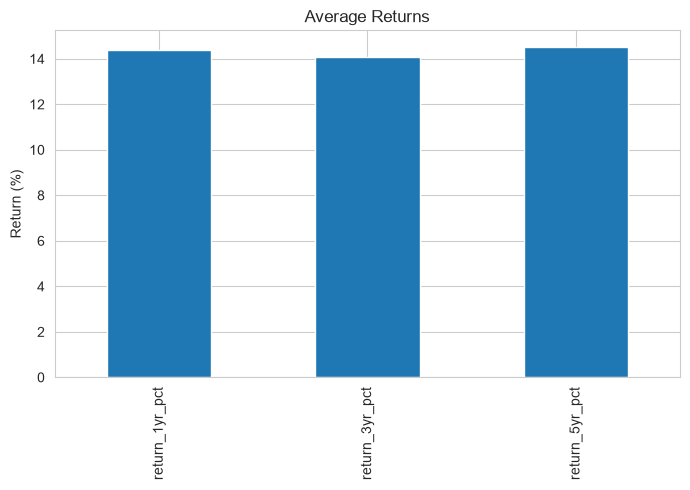

In [23]:
returns = performance[["return_1yr_pct","return_3yr_pct","return_5yr_pct"]].mean()

plt.figure(figsize=(7,5))
returns.plot(kind="bar")

plt.title("Average Returns")
plt.ylabel("Return (%)")

plt.tight_layout()
plt.savefig("../dashboard/charts/average_returns.png")
plt.show()

Chart 13: Industry Folio Growth

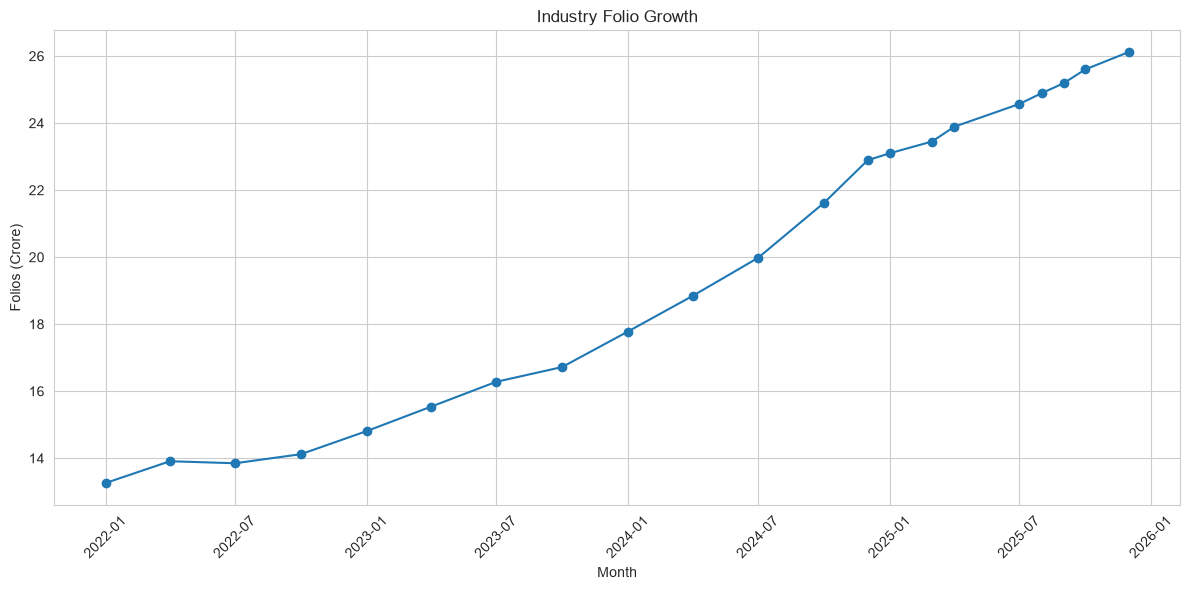

In [24]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))
plt.plot(folio["month"], folio["total_folios_crore"], marker="o")

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../dashboard/charts/folio_growth.png")
plt.show()

Chart 14: Category-wise Average Returns

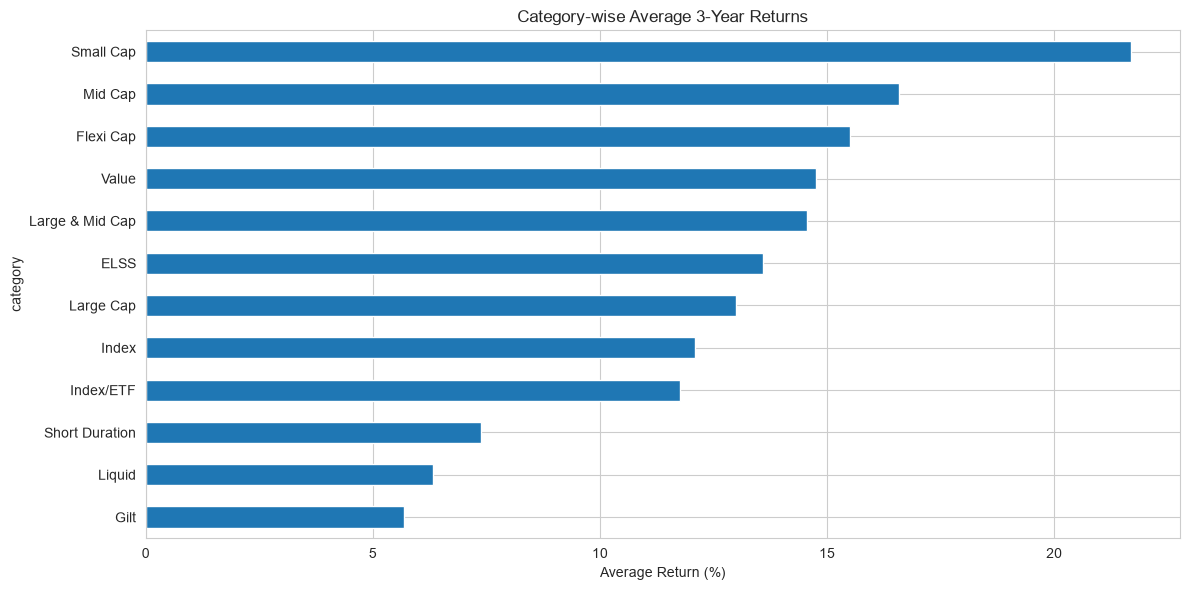

In [25]:
category_returns = performance.groupby("category")["return_3yr_pct"].mean().sort_values()

plt.figure(figsize=(12,6))
category_returns.plot(kind="barh")

plt.title("Category-wise Average 3-Year Returns")
plt.xlabel("Average Return (%)")

plt.tight_layout()
plt.savefig("../dashboard/charts/category_returns.png")
plt.show()

Chart 15: Correlation Heatmap

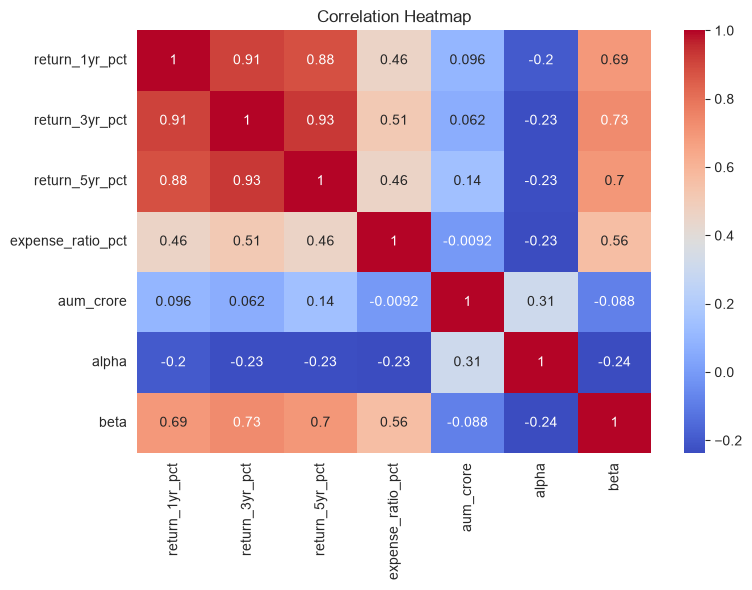

In [26]:
import seaborn as sns

corr = performance[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "expense_ratio_pct",
        "aum_crore",
        "alpha",
        "beta"
    ]
].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("../dashboard/charts/correlation_heatmap.png")
plt.show()